# Dataset de vocales: separación por persona y duración uniforme

## Resumen

Los datos originales contienen **100 personas** (50 `Control`, 50 `Patologicas`) y **1500 grabaciones**: cinco vocales con tres repeticiones por persona.

La división estratificada por persona produce **70 para train (35+35)**, **10 para val (5+5)** y **20 para test (10+10)**. Los cinco folds se forman exclusivamente dentro de `train`: cada uno tiene 28+28 personas para entrenamiento interno y 7+7 para validación interna.

**Durante la evolución de la arquitectura**, usar los folds de `train` y consultar `val` para seguir su progreso. `val` forma parte del desarrollo y puede influir en la selección. **`test` se evalúa al final de todo**, una vez fijados arquitectura, hiperparámetros y reglas de entrenamiento.

El notebook genera 1500 WAV de **6,5 s**, 44,1 kHz y 286 650 muestras, junto con manifiestos CSV. Los audios originales no se modifican.

Tambien se exportan dos entradas .npy para la CNN: la onda de audio y el espectrograma log-mel. Cada una tiene un archivo por grabacion, arrays para los cinco folds de train y un unico array global por particion.

## Contexto y método

El identificador de persona se lee del nombre `AVPEPUDEA[C]NNNNvR.wav`: `C` indica control, `NNNN` es el número de persona, `v` la vocal y `R` la repetición. La clase forma parte del identificador para evitar colisiones. Cada persona debe tener cinco vocales y tres repeticiones por vocal.

**Protocolo de desarrollo:** en cada fold se entrena con 56 personas de `train` y se evalúa con otras 14 personas de `train`. `val.csv` es un conjunto separado de 10 personas, disponible durante el entrenamiento para visualizar la evolución por época o generación y comparar arquitecturas. Como se consulta repetidamente, sus métricas **no son una estimación final independiente**. El modelo final se fija usando `train` y `val`; entonces se evalúa **una única vez** en `test.csv` y no se ajusta de nuevo tras ver ese resultado.

### Supuestos clave

- Las carpetas `Control` y `Patologicas` son las etiquetas binarias proporcionadas; el notebook no hace inferencias clínicas.
- El objetivo de duración se fija con el percentil 95 de los **audios de entrenamiento**, redondeado hacia arriba a décimas de segundo. Ni `val` ni `test` determinan este parámetro.
- Un audio largo se recorta a la ventana continua con mayor energía. Un audio corto se rellena simétricamente con silencio. La misma regla fija se aplica a todas las particiones.
- Se conserva la frecuencia original de 44,1 kHz y el formato PCM de 16 bits si todos los archivos cumplen la comprobación inicial.


## Datos

### 1. Configuración y rutas

In [1]:
from pathlib import Path
import re
import wave

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import wavfile
from sklearn.model_selection import StratifiedKFold, train_test_split

SEED = 42
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.10
TEST_FRACTION = 0.20
N_FOLDS = 5
DURATION_QUANTILE = 0.95

def locate_repo(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "new_data" / "vowels").is_dir():
            return candidate
    raise FileNotFoundError("No se encuentra new_data/vowels desde el directorio actual")

REPO_ROOT = locate_repo(Path.cwd())
SOURCE_ROOT = REPO_ROOT / "new_data" / "vowels"
OUTPUT_ROOT = REPO_ROOT / "artifacts" / "vowels_dataset"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print("Fuente:", SOURCE_ROOT)
print("Salida:", OUTPUT_ROOT)


Fuente: G:\Neuroevolution-ipynbs\new_data\vowels
Salida: G:\Neuroevolution-ipynbs\artifacts\vowels_dataset


### 2. Inventario y comprobación de nombres y WAV

In [2]:
NAME_PATTERN = re.compile(r"^AVPEPUDEA(?P<control>C?)(?P<number>\d{4})(?P<vowel>[aeiou])(?P<repetition>[123])\.wav$", re.IGNORECASE)
EXPECTED_VOWELS = set("AEIOU")
EXPECTED_REPETITIONS = {1, 2, 3}
records = []
errors = []

for path in sorted(SOURCE_ROOT.rglob("*")):
    if not path.is_file():
        continue
    relative = path.relative_to(SOURCE_ROOT)
    if len(relative.parts) != 3 or path.suffix.lower() != ".wav":
        errors.append(f"Ruta inesperada: {relative}")
        continue
    folder_class, folder_vowel, _ = relative.parts
    match = NAME_PATTERN.fullmatch(path.name)
    if match is None:
        errors.append(f"Nombre inesperado: {relative}")
        continue
    name_class = "Control" if match.group("control") else "Patologicas"
    vowel = match.group("vowel").upper()
    if folder_class != name_class or folder_vowel.upper() != vowel:
        errors.append(f"Carpeta y nombre no coinciden: {relative}")
        continue
    try:
        with wave.open(str(path), "rb") as audio:
            sample_rate = audio.getframerate()
            channels = audio.getnchannels()
            sample_width = audio.getsampwidth()
            n_samples = audio.getnframes()
            compression = audio.getcomptype()
    except (wave.Error, OSError) as exc:
        errors.append(f"WAV ilegible: {relative}: {exc}")
        continue
    person_id = f"{name_class}_{match.group('number')}"
    records.append({
        "person_id": person_id,
        "label": name_class,
        "label_binary": int(name_class == "Patologicas"),
        "vowel": vowel,
        "repetition": int(match.group("repetition")),
        "source_path": relative.as_posix(),
        "sample_rate_hz": sample_rate,
        "channels": channels,
        "sample_width_bytes": sample_width,
        "compression": compression,
        "raw_samples": n_samples,
        "raw_duration_s": n_samples / sample_rate,
    })

assert not errors, "\n".join(errors[:20])
manifest = pd.DataFrame.from_records(records).sort_values(
    ["label", "person_id", "vowel", "repetition"]
).reset_index(drop=True)
assert not manifest.empty, "No hay audios"
assert not manifest.duplicated(["person_id", "vowel", "repetition"]).any()
configurations = manifest[["sample_rate_hz", "channels", "sample_width_bytes", "compression"]].drop_duplicates()
assert len(configurations) == 1, "Los WAV tienen configuraciones distintas; revisar antes de normalizar"
assert (manifest["channels"].iloc[0], manifest["sample_width_bytes"].iloc[0], manifest["compression"].iloc[0]) == (1, 2, "NONE"), "Se requiere PCM mono de 16 bits"

print(f"{len(manifest)} WAV; {manifest.person_id.nunique()} personas")
display(manifest.groupby(["label", "vowel"]).agg(personas=("person_id", "nunique"), audios=("source_path", "size")))
display(configurations)


1500 WAV; 100 personas


personas  audios
label       vowel                  
Control     A            50     150
            E            50     150
            I            50     150
            O            50     150
            U            50     150
Patologicas A            50     150
            E            50     150
            I            50     150
            O            50     150
            U            50     150

,sample_rate_hz,channels,sample_width_bytes,compression
0,44100,1,2,NONE


### 3. Comprobar que cada persona tiene sus 15 grabaciones

In [3]:
expected_pairs = {(vowel, repetition) for vowel in EXPECTED_VOWELS for repetition in EXPECTED_REPETITIONS}
incomplete = {}
for person_id, person_rows in manifest.groupby("person_id"):
    actual_pairs = set(zip(person_rows.vowel, person_rows.repetition))
    if actual_pairs != expected_pairs:
        incomplete[person_id] = {
            "faltan": sorted(expected_pairs - actual_pairs),
            "sobran": sorted(actual_pairs - expected_pairs),
        }
assert not incomplete, f"Personas incompletas: {incomplete}"
assert manifest.groupby("person_id").label.nunique().eq(1).all()

people = manifest[["person_id", "label", "label_binary"]].drop_duplicates().sort_values("person_id").reset_index(drop=True)
print("Personas por clase:")
display(people.label.value_counts().rename_axis("clase").to_frame("personas"))
print("Todas las personas tienen cinco vocales × tres repeticiones.")


Personas por clase:


,personas
clase,
Control,50
Patologicas,50


Todas las personas tienen cinco vocales × tres repeticiones.


## Resultados

### 4. Separar personas: 70 train, 10 val y 20 test


label,Control,Patologicas,total
split,,,
train,35,35,70
val,5,5,10
test,10,10,20


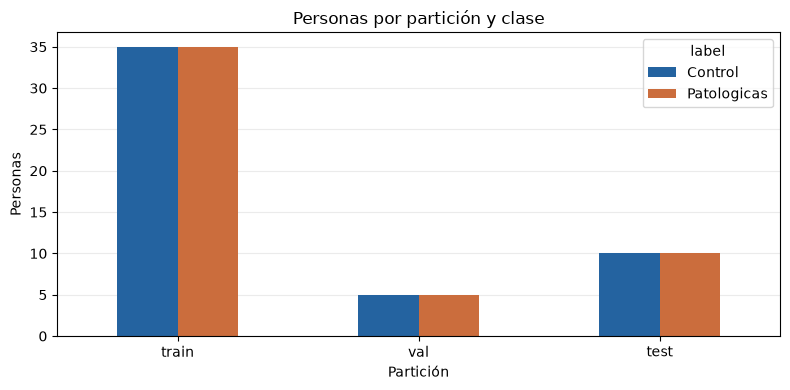

In [4]:
assert abs(TRAIN_FRACTION + VAL_FRACTION + TEST_FRACTION - 1.0) < 1e-12
number_of_people = len(people)
n_val = round(number_of_people * VAL_FRACTION)
n_test = round(number_of_people * TEST_FRACTION)
n_train = number_of_people - n_val - n_test
assert (n_train, n_val, n_test) == (70, 10, 20)
train_people, reserved_people = train_test_split(
    people, test_size=n_val + n_test,
    stratify=people.label_binary, random_state=SEED,
)
val_people, test_people = train_test_split(
    reserved_people, test_size=n_test,
    stratify=reserved_people.label_binary, random_state=SEED,
)
split_lookup = {
    **{person_id: "train" for person_id in train_people.person_id},
    **{person_id: "val" for person_id in val_people.person_id},
    **{person_id: "test" for person_id in test_people.person_id},
}
assert len(split_lookup) == len(people)
manifest["split"] = manifest.person_id.map(split_lookup)
people["split"] = people.person_id.map(split_lookup)
split_counts = people.groupby(["split", "label"]).size().unstack(fill_value=0).reindex(["train", "val", "test"])
display(split_counts.assign(total=split_counts.sum(axis=1)))
assert (split_counts.sum(axis=1).to_numpy() == [70, 10, 20]).all()
assert (split_counts["Control"] == split_counts["Patologicas"]).all()

ax = split_counts.plot.bar(figsize=(8, 4), color=["#2463a0", "#cb6d3d"], rot=0)
ax.set(title="Personas por partición y clase", xlabel="Partición", ylabel="Personas")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()



### 5. Cinco folds estratificados dentro de train

La columna `cv_fold` indica en qué fold actúa cada persona como **validación interna**. Para el fold `k`, se entrena con personas de `train` cuyo `cv_fold != k`. `val` sirve para monitorizar la arquitectura durante el desarrollo y no tiene número de fold; `test` tampoco, porque se reserva para la evaluación final.


In [5]:
train_people_sorted = people.loc[people.split.eq("train")].sort_values("person_id").reset_index(drop=True)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_lookup = {}
for fold, (_, fold_val_indices) in enumerate(skf.split(train_people_sorted.person_id, train_people_sorted.label_binary)):
    for person_id in train_people_sorted.iloc[fold_val_indices].person_id:
        fold_lookup[person_id] = fold
assert len(fold_lookup) == len(train_people_sorted)
manifest["cv_fold"] = manifest.person_id.map(fold_lookup).astype("Int64")
people["cv_fold"] = people.person_id.map(fold_lookup).astype("Int64")
fold_counts = people.loc[people.split.eq("train")].groupby(["cv_fold", "label"]).size().unstack(fill_value=0)
display(fold_counts.assign(total=fold_counts.sum(axis=1)))
assert (fold_counts["Control"] == 7).all() and (fold_counts["Patologicas"] == 7).all()
for fold in range(N_FOLDS):
    inner_val_people = people.loc[people.cv_fold.eq(fold).fillna(False)]
    inner_train_people = people.loc[people.split.eq("train") & ~people.cv_fold.eq(fold).fillna(False)]
    assert inner_val_people.label.value_counts().to_dict() == {"Control": 7, "Patologicas": 7}
    assert inner_train_people.label.value_counts().to_dict() == {"Control": 28, "Patologicas": 28}
print("Cada fold: entrenamiento interno 28+28 personas; validación interna 7+7.")


label,Control,Patologicas,total
cv_fold,,,
0,7,7,14
1,7,7,14
2,7,7,14
3,7,7,14
4,7,7,14


Cada fold: entrenamiento interno 28+28 personas; validación interna 7+7.


### 6. Auditar la ausencia de fugas entre personas

In [6]:
split_sets = {split: set(people.loc[people.split.eq(split), "person_id"]) for split in ("train", "val", "test")}
for split in ("train", "val", "test"):
    class_counts = manifest.loc[manifest.split.eq(split), "label"].value_counts()
    assert class_counts["Control"] == class_counts["Patologicas"]
assert split_sets["train"].isdisjoint(split_sets["val"])
assert split_sets["train"].isdisjoint(split_sets["test"])
assert split_sets["val"].isdisjoint(split_sets["test"])
assert split_sets["train"] | split_sets["val"] | split_sets["test"] == set(people.person_id)
assert manifest.groupby("person_id").split.nunique().eq(1).all()
assert manifest.groupby("person_id").cv_fold.nunique(dropna=False).eq(1).all()
assert manifest.loc[manifest.split.ne("train"), "cv_fold"].isna().all()
for fold in range(N_FOLDS):
    inner_val = set(people.loc[people.cv_fold.eq(fold).fillna(False), "person_id"])
    inner_train = split_sets["train"] - inner_val
    assert inner_train.isdisjoint(inner_val)
    assert (inner_train | inner_val) == split_sets["train"]
    assert inner_val.isdisjoint(split_sets["val"] | split_sets["test"])
print("Sin personas compartidas entre particiones ni entre train/validación interna de cada fold.")


Sin personas compartidas entre particiones ni entre train/validación interna de cada fold.


### 7. Fijar la duración usando solo train

La siguiente figura usa exclusivamente las cabeceras WAV de `train`. La duración objetivo queda congelada antes de transformar las particiones.


Frecuencia: 44,100 Hz
Objetivo: 6.5 s = 286,650 muestras
Audios de train que requieren recorte: 48/1050 (4.6%)


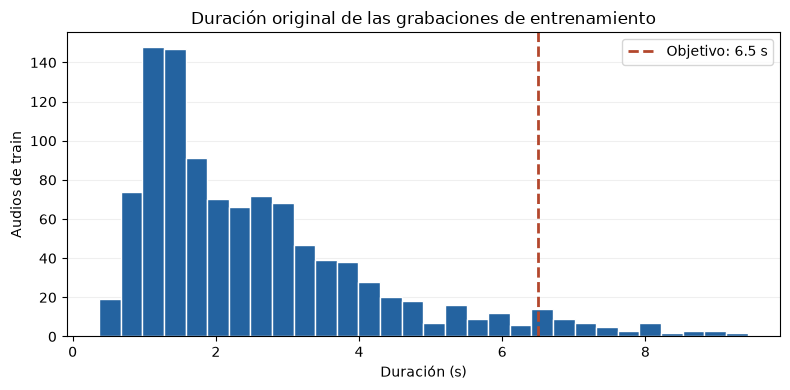

In [7]:
train_durations = manifest.loc[manifest.split.eq("train"), "raw_duration_s"].to_numpy()
sample_rate_hz = int(manifest.sample_rate_hz.iloc[0])
target_duration_s = float(np.ceil(np.quantile(train_durations, DURATION_QUANTILE) * 10) / 10)
target_samples = int(round(target_duration_s * sample_rate_hz))
train_over_target = int((train_durations > target_duration_s).sum())
print(f"Frecuencia: {sample_rate_hz:,} Hz")
print(f"Objetivo: {target_duration_s:.1f} s = {target_samples:,} muestras")
print(f"Audios de train que requieren recorte: {train_over_target}/{len(train_durations)} ({train_over_target / len(train_durations):.1%})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_durations, bins=30, color="#2463a0", edgecolor="white")
ax.axvline(target_duration_s, color="#b3472d", linestyle="--", linewidth=2, label=f"Objetivo: {target_duration_s:.1f} s")
ax.set(title="Duración original de las grabaciones de entrenamiento", xlabel="Duración (s)", ylabel="Audios de train")
ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 8. Normalizar duración y escribir WAV

El recorte selecciona la ventana con más energía, calculada **dentro de cada audio**; no utiliza estadísticas de otros audios. El relleno usa ceros a ambos lados. Se conserva el PCM original de 16 bits y la estructura `split/clase/vocal/archivo.wav`.


In [8]:
def normalize_duration(samples: np.ndarray, n_target: int) -> tuple[np.ndarray, str, int]:
    if len(samples) == n_target:
        return samples.copy(), "igual", 0
    if len(samples) < n_target:
        missing = n_target - len(samples)
        left = missing // 2
        return np.pad(samples, (left, missing - left), mode="constant"), "relleno", 0
    squared = samples.astype(np.float32) ** 2
    cumulative = np.empty(len(samples) + 1, dtype=np.float64)
    cumulative[0] = 0.0
    np.cumsum(squared, dtype=np.float64, out=cumulative[1:])
    window_energies = cumulative[n_target:] - cumulative[:-n_target]
    start = int(np.argmax(window_energies))
    return samples[start:start + n_target].copy(), "recorte", start

processing = []
for row in manifest.itertuples(index=False):
    source = SOURCE_ROOT / row.source_path
    rate, samples = wavfile.read(source)
    assert rate == sample_rate_hz and samples.dtype == np.int16 and samples.ndim == 1
    assert len(samples) == row.raw_samples
    normalized, operation, start = normalize_duration(samples, target_samples)
    assert len(normalized) == target_samples and normalized.dtype == np.int16
    output_relative = Path(row.split) / row.label / row.vowel / source.name
    output_path = OUTPUT_ROOT / output_relative
    output_path.parent.mkdir(parents=True, exist_ok=True)
    wavfile.write(output_path, sample_rate_hz, normalized)
    processing.append((output_relative.as_posix(), operation, start))

manifest[["processed_path", "duration_operation", "crop_start_sample"]] = pd.DataFrame(processing, index=manifest.index)
manifest["processed_samples"] = target_samples
manifest["processed_duration_s"] = target_duration_s
print(f"Procesados {len(manifest)} audios en {OUTPUT_ROOT}")
print("Operaciones en train:")
display(manifest.loc[manifest.split.eq("train"), "duration_operation"].value_counts().rename_axis("operación").to_frame("audios"))


Procesados 1500 audios en G:\Neuroevolution-ipynbs\artifacts\vowels_dataset
Operaciones en train:


,audios
operación,
relleno,1002
recorte,48


### 9. Guardar manifiestos y comprobar las salidas

`manifest.csv` tiene una fila por audio. `people.csv` tiene una fila por persona. Los cinco pares `fold_k_train.csv` y `fold_k_val.csv` contienen únicamente archivos de la partición `train`; esta `val` es **interna** al fold y distinta de `val.csv`, que sirve para monitorizar la evolución de la arquitectura. `test.csv` se evalúa al final.


In [9]:
manifest.to_csv(OUTPUT_ROOT / "manifest.csv", index=False)
people.to_csv(OUTPUT_ROOT / "people.csv", index=False)
for split in ("train", "val", "test"):
    manifest.loc[manifest.split.eq(split)].to_csv(OUTPUT_ROOT / f"{split}.csv", index=False)
for fold in range(N_FOLDS):
    is_inner_val = manifest.cv_fold.eq(fold).fillna(False)
    manifest.loc[manifest.split.eq("train") & ~is_inner_val].to_csv(OUTPUT_ROOT / f"fold_{fold}_train.csv", index=False)
    manifest.loc[manifest.split.eq("train") & is_inner_val].to_csv(OUTPUT_ROOT / f"fold_{fold}_val.csv", index=False)

assert len(manifest) == len(list(OUTPUT_ROOT.rglob("*.wav")))
assert manifest.processed_samples.nunique() == 1
assert manifest.processed_duration_s.nunique() == 1
assert all((OUTPUT_ROOT / relative).is_file() for relative in manifest.processed_path)
for relative in manifest.processed_path:
    with wave.open(str(OUTPUT_ROOT / relative), "rb") as audio:
        assert audio.getnframes() == target_samples
        assert audio.getframerate() == sample_rate_hz
        assert audio.getnchannels() == 1 and audio.getsampwidth() == 2
print("Verificados los 1500 WAV procesados: misma duración y configuración.")
print("Manifiestos guardados en:", OUTPUT_ROOT)


Verificados los 1500 WAV procesados: misma duración y configuración.
Manifiestos guardados en: G:\Neuroevolution-ipynbs\artifacts\vowels_dataset


## Conclusiones y uso posterior

- Para comparar candidatos, usar `fold_0_train.csv`/`fold_0_val.csv` hasta `fold_4_train.csv`/`fold_4_val.csv`. Cada persona tiene todas sus vocales y repeticiones juntas dentro de cada fold.
- Durante el desarrollo, consultar `val.csv` para seguir el rendimiento por época o generación. Se permite usar esa información al elegir arquitectura o detener el entrenamiento; por ello, **no** presentar su resultado como evaluación independiente final.
- Una vez fijado el procedimiento completo, entrenar la versión final con los datos de desarrollo según el protocolo elegido. Abrir `test.csv` y calcular sus métricas **una sola vez**, al final. No modificar el procedimiento después de verlas.
- Leer `processed_path` relativo a `artifacts/vowels_dataset/`. `source_path` es relativo a `new_data/vowels/`. La etiqueta binaria es `0 = Control`, `1 = Patologicas`.
- El percentil 95 calculado sobre `train` fijó 6,5 s; 48 de los 1050 audios de entrenamiento (4,6 %) se recortaron; `duration_operation` y `crop_start_sample` dejan esa decisión auditable.


## Exportación de las dos entradas `.npy`

Se guardan **ambas representaciones por audio**, siempre después de normalizar los WAV a 6,5 s:

- `npy_audio/` y `arrays_audio/`: la onda original en `float32`, escalada de PCM16 a [-1, 1), con forma `(1, 286650)`. Es la opción `audio` del modelo.
- `npy/` y `arrays/`: espectrograma log-mel de 64 bandas con forma `(64, 648)`. Es la opcion `spectrogram`: la CNN 2D lo trata como un mapa de frecuencia y tiempo con un canal.

La transformación es fija e independiente por grabación; no se ajustan parámetros con `val` ni `test`. Los CSV incorporan rutas a las dos representaciones. Los arrays de folds contienen exclusivamente personas de `train`; el único test es global y se reserva para después de elegir la arquitectura.

In [10]:
import json
from scipy.io import wavfile
from scipy.signal import stft

N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 441
MIN_HZ, MAX_HZ = 80.0, 8000.0
FEATURE_ID = "vowels"
ARRAY_ROOT = OUTPUT_ROOT / "arrays"
ARRAY_ROOT.mkdir(parents=True, exist_ok=True)

frequencies = np.fft.rfftfreq(N_FFT, 1 / sample_rate_hz)
def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)
def mel_to_hz(mel):
    return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

edges = mel_to_hz(np.linspace(hz_to_mel(MIN_HZ), hz_to_mel(MAX_HZ), N_MELS + 2))
mel_filters = np.zeros((N_MELS, len(frequencies)), dtype=np.float32)
for band in range(N_MELS):
    left, center, right = edges[band:band + 3]
    mel_filters[band] = np.maximum(
        0.0,
        np.minimum((frequencies - left) / (center - left), (right - frequencies) / (right - center)),
    )
    mel_filters[band] /= max(float(mel_filters[band].sum()), 1e-12)

def wav_to_log_mel(path: Path) -> np.ndarray:
    rate, samples = wavfile.read(path)
    assert rate == sample_rate_hz and samples.dtype == np.int16 and samples.ndim == 1
    assert len(samples) == target_samples
    signal = samples.astype(np.float32) / 32768.0
    _, _, spectrum = stft(
        signal, fs=rate, nperseg=N_FFT, noverlap=N_FFT - HOP_LENGTH,
        boundary=None, padded=False,
    )
    power = np.abs(spectrum).astype(np.float32) ** 2
    return np.ascontiguousarray(np.log1p(1000.0 * (mel_filters @ power)), dtype=np.float32)

feature_paths = []
feature_shape = None
for row in manifest.itertuples(index=False):
    relative = Path("npy") / row.split / row.label / row.vowel / (Path(row.processed_path).stem + ".npy")
    destination = OUTPUT_ROOT / relative
    destination.parent.mkdir(parents=True, exist_ok=True)
    features = wav_to_log_mel(OUTPUT_ROOT / row.processed_path)
    if feature_shape is None:
        feature_shape = features.shape
    assert features.shape == feature_shape and np.isfinite(features).all()
    np.save(destination, features)
    feature_paths.append(relative.as_posix())

manifest["feature_npy_path"] = feature_paths
manifest["feature_channels"] = feature_shape[0]
manifest["feature_frames"] = feature_shape[1]
print(f"{len(manifest)} archivos .npy individuales; forma por audio: {feature_shape}")

feature_config = {
    "representation": "log_mel_power",
    "source_sample_rate_hz": sample_rate_hz,
    "source_samples": target_samples,
    "n_mels": N_MELS,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "min_hz": MIN_HZ,
    "max_hz": MAX_HZ,
    "shape": list(feature_shape),
    "dtype": "float32",
    "scale": "log1p(1000 * mel_power)",
}
with (OUTPUT_ROOT / "feature_config.json").open("w", encoding="utf-8") as stream:
    json.dump(feature_config, stream, indent=2)


1500 archivos .npy individuales; forma por audio: (64, 648)


### Arrays por fold y por partición

Los índices de cada array siguen exactamente el orden de su CSV. Se escriben de forma incremental para evitar cargar todas las copias en RAM. Los folds del notebook se llaman 0–4; para los nombres `.npy` usados por el entrenamiento se numeran 1–5.


In [11]:
def write_array_pair(rows: pd.DataFrame, split_name: str, suffix: str) -> None:
    x_path = ARRAY_ROOT / f"X_{split_name}_{FEATURE_ID}{suffix}.npy"
    y_path = ARRAY_ROOT / f"y_{split_name}_{FEATURE_ID}{suffix}.npy"
    x_array = np.lib.format.open_memmap(x_path, mode="w+", dtype=np.float32, shape=(len(rows), *feature_shape))
    y_array = np.lib.format.open_memmap(y_path, mode="w+", dtype=np.int64, shape=(len(rows),))
    for index, row in enumerate(rows.itertuples(index=False)):
        x_array[index] = np.load(OUTPUT_ROOT / row.feature_npy_path)
        y_array[index] = row.label_binary
    x_array.flush()
    y_array.flush()
    del x_array, y_array

# Exportar los arrays log-mel. La última celda añadirá las rutas de audio a los CSV.
manifest["image_npy_path"] = manifest["feature_npy_path"]
manifest.to_csv(OUTPUT_ROOT / "manifest.csv", index=False)
for split in ("train", "val", "test"):
    rows = manifest.loc[manifest.split.eq(split)].copy()
    rows.to_csv(OUTPUT_ROOT / f"{split}.csv", index=False)
    write_array_pair(rows, split, "")

for fold in range(N_FOLDS):
    is_inner_val = manifest.cv_fold.eq(fold).fillna(False)
    train_rows = manifest.loc[manifest.split.eq("train") & ~is_inner_val].copy()
    inner_val_rows = manifest.loc[manifest.split.eq("train") & is_inner_val].copy()
    train_rows.to_csv(OUTPUT_ROOT / f"fold_{fold}_train.csv", index=False)
    inner_val_rows.to_csv(OUTPUT_ROOT / f"fold_{fold}_val.csv", index=False)
    write_array_pair(train_rows, "train", f"_fold_{fold + 1}")
    write_array_pair(inner_val_rows, "val", f"_fold_{fold + 1}")

assert not list(ARRAY_ROOT.glob("*test*fold*.npy")), "No se debe duplicar test por fold"
for split, expected_people, expected_audios in (("train", 70, 1050), ("val", 10, 150), ("test", 20, 300)):
    rows = manifest.loc[manifest.split.eq(split)]
    assert rows.person_id.nunique() == expected_people and len(rows) == expected_audios
    assert rows.groupby("label").person_id.nunique().to_dict() == {
        "Control": expected_people // 2, "Patologicas": expected_people // 2,
    }
    x = np.load(ARRAY_ROOT / f"X_{split}_{FEATURE_ID}.npy", mmap_mode="r")
    y = np.load(ARRAY_ROOT / f"y_{split}_{FEATURE_ID}.npy", mmap_mode="r")
    assert x.shape == (expected_audios, *feature_shape) and y.shape == (expected_audios,)
    assert np.array_equal(y, rows.label_binary.to_numpy())

for fold in range(N_FOLDS):
    inner_train = manifest.loc[manifest.split.eq("train") & ~manifest.cv_fold.eq(fold).fillna(False)]
    inner_val = manifest.loc[manifest.split.eq("train") & manifest.cv_fold.eq(fold).fillna(False)]
    assert set(inner_train.person_id).isdisjoint(inner_val.person_id)
    assert set(inner_val.person_id).isdisjoint(manifest.loc[manifest.split.eq("test"), "person_id"])
    assert np.load(ARRAY_ROOT / f"X_train_{FEATURE_ID}_fold_{fold + 1}.npy", mmap_mode="r").shape == (840, *feature_shape)
    assert np.load(ARRAY_ROOT / f"X_val_{FEATURE_ID}_fold_{fold + 1}.npy", mmap_mode="r").shape == (210, *feature_shape)

display(pd.DataFrame({
    "partición": ["train", "val", "test", "cada fold train", "cada fold val"],
    "personas": [70, 10, 20, 56, 14],
    "audios": [1050, 150, 300, 840, 210],
    "clase 0 / clase 1": ["35 / 35", "5 / 5", "10 / 10", "28 / 28", "7 / 7"],
}))
print("Arrays .npy y CSV verificados en:", ARRAY_ROOT)


,partición,personas,audios,clase 0 / clase 1
0,train,70,1050,35 / 35
1,val,10,150,5 / 5
2,test,20,300,10 / 10
3,cada fold train,56,840,28 / 28
4,cada fold val,14,210,7 / 7


Arrays .npy y CSV verificados en: G:\Neuroevolution-ipynbs\artifacts\vowels_dataset\arrays


### Onda de audio original en `.npy`

Cada archivo guarda la señal PCM16 normalizada a `float32` sin convertirla en espectrograma. Los arrays agregados usan exactamente el orden de los CSV y la misma separación de personas que los arrays log-mel.

In [12]:
AUDIO_ARRAY_ROOT = OUTPUT_ROOT / "arrays_audio"
AUDIO_ARRAY_ROOT.mkdir(parents=True, exist_ok=True)
audio_paths = []
audio_shape = (1, target_samples)

for row in manifest.itertuples(index=False):
    relative = Path("npy_audio") / row.split / row.label / row.vowel / (Path(row.processed_path).stem + ".npy")
    destination = OUTPUT_ROOT / relative
    destination.parent.mkdir(parents=True, exist_ok=True)
    rate, samples = wavfile.read(OUTPUT_ROOT / row.processed_path)
    assert rate == sample_rate_hz and samples.dtype == np.int16 and samples.shape == (target_samples,)
    waveform = (samples.astype(np.float32) / 32768.0)[None, :]
    np.save(destination, waveform)
    audio_paths.append(relative.as_posix())

manifest["audio_npy_path"] = audio_paths
manifest["audio_channels"] = 1
manifest["audio_samples"] = target_samples
print(f"{len(manifest)} ondas .npy individuales; forma por audio: {audio_shape}")

audio_config = {
    "representation": "pcm16_waveform_scaled_float32",
    "source_sample_rate_hz": sample_rate_hz,
    "source_samples": target_samples,
    "shape": list(audio_shape),
    "dtype": "float32",
    "scale": "pcm16 / 32768",
}
with (OUTPUT_ROOT / "audio_config.json").open("w", encoding="utf-8") as stream:
    json.dump(audio_config, stream, indent=2)


1500 ondas .npy individuales; forma por audio: (1, 286650)


### Arrays de audio por fase y fold

Se comprueban formas, etiquetas, equilibrio de clases y ausencia de archivos de test por fold para las dos modalidades.

In [13]:
def write_audio_array_pair(rows: pd.DataFrame, split_name: str, suffix: str) -> None:
    x_path = AUDIO_ARRAY_ROOT / f"X_{split_name}_{FEATURE_ID}{suffix}.npy"
    y_path = AUDIO_ARRAY_ROOT / f"y_{split_name}_{FEATURE_ID}{suffix}.npy"
    x_array = np.lib.format.open_memmap(x_path, mode="w+", dtype=np.float32, shape=(len(rows), *audio_shape))
    y_array = np.lib.format.open_memmap(y_path, mode="w+", dtype=np.int64, shape=(len(rows),))
    for index, row in enumerate(rows.itertuples(index=False)):
        x_array[index] = np.load(OUTPUT_ROOT / row.audio_npy_path)
        y_array[index] = row.label_binary
    x_array.flush()
    y_array.flush()
    del x_array, y_array

# Reescribir todos los CSV después de incorporar las rutas de ambas modalidades.
manifest.to_csv(OUTPUT_ROOT / "manifest.csv", index=False)
for split in ("train", "val", "test"):
    rows = manifest.loc[manifest.split.eq(split)].copy()
    rows.to_csv(OUTPUT_ROOT / f"{split}.csv", index=False)
    write_audio_array_pair(rows, split, "")

for fold in range(N_FOLDS):
    is_inner_val = manifest.cv_fold.eq(fold).fillna(False)
    train_rows = manifest.loc[manifest.split.eq("train") & ~is_inner_val].copy()
    inner_val_rows = manifest.loc[manifest.split.eq("train") & is_inner_val].copy()
    train_rows.to_csv(OUTPUT_ROOT / f"fold_{fold}_train.csv", index=False)
    inner_val_rows.to_csv(OUTPUT_ROOT / f"fold_{fold}_val.csv", index=False)
    write_audio_array_pair(train_rows, "train", f"_fold_{fold + 1}")
    write_audio_array_pair(inner_val_rows, "val", f"_fold_{fold + 1}")

assert not list(AUDIO_ARRAY_ROOT.glob("*test*fold*.npy"))
for split, expected_audios in (("train", 1050), ("val", 150), ("test", 300)):
    rows = manifest.loc[manifest.split.eq(split)]
    for root, shape, path_column in (
        (ARRAY_ROOT, feature_shape, "image_npy_path"),
        (AUDIO_ARRAY_ROOT, audio_shape, "audio_npy_path"),
    ):
        assert all((OUTPUT_ROOT / relative).is_file() for relative in rows[path_column])
        x = np.load(root / f"X_{split}_{FEATURE_ID}.npy", mmap_mode="r")
        y = np.load(root / f"y_{split}_{FEATURE_ID}.npy", mmap_mode="r")
        assert x.shape == (expected_audios, *shape)
        assert np.array_equal(y, rows.label_binary.to_numpy())

for fold in range(N_FOLDS):
    for split, expected_audios in (("train", 840), ("val", 210)):
        rows = pd.read_csv(OUTPUT_ROOT / f"fold_{fold}_{split}.csv")
        for root, shape in ((ARRAY_ROOT, feature_shape), (AUDIO_ARRAY_ROOT, audio_shape)):
            x = np.load(root / f"X_{split}_{FEATURE_ID}_fold_{fold + 1}.npy", mmap_mode="r")
            y = np.load(root / f"y_{split}_{FEATURE_ID}_fold_{fold + 1}.npy", mmap_mode="r")
            assert x.shape == (expected_audios, *shape)
            assert np.array_equal(y, rows.label_binary.to_numpy())

example = manifest.iloc[0]
_, example_pcm = wavfile.read(OUTPUT_ROOT / example.processed_path)
assert np.array_equal(
    np.load(OUTPUT_ROOT / example.audio_npy_path)[0],
    example_pcm.astype(np.float32) / 32768.0,
)
print("Audio y log-mel verificados: 1500 grabaciones, 5 folds equilibrados y test global aislado.")
display(manifest[["person_id", "split", "cv_fold", "label", "audio_npy_path", "image_npy_path"]].head())


Audio y log-mel verificados: 1500 grabaciones, 5 folds equilibrados y test global aislado.


,person_id,split,cv_fold,label,audio_npy_path,image_npy_path
0,Control_0001,train,3,Control,npy_audio/train/Control/A/AVPEPUDEAC0001a1.npy,npy/train/Control/A/AVPEPUDEAC0001a1.npy
1,Control_0001,train,3,Control,npy_audio/train/Control/A/AVPEPUDEAC0001a2.npy,npy/train/Control/A/AVPEPUDEAC0001a2.npy
2,Control_0001,train,3,Control,npy_audio/train/Control/A/AVPEPUDEAC0001a3.npy,npy/train/Control/A/AVPEPUDEAC0001a3.npy
3,Control_0001,train,3,Control,npy_audio/train/Control/E/AVPEPUDEAC0001e1.npy,npy/train/Control/E/AVPEPUDEAC0001e1.npy
4,Control_0001,train,3,Control,npy_audio/train/Control/E/AVPEPUDEAC0001e2.npy,npy/train/Control/E/AVPEPUDEAC0001e2.npy


## Uso en el entrenamiento

En `neuroevolution/config.py`, cambiar `CONFIG["input_modality"]` entre `"audio"` (onda, valor predeterminado) y `"spectrogram"` (log-mel con CNN 2D). `test.ipynb` selecciona automáticamente el directorio de arrays correspondiente. `val` monitoriza la evolución; `test` solo se carga tras fijar la arquitectura.